# Follow Up Ensemble Detection

In [2]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')
load('ROI_positions.mat')

In [148]:
%Variables
thrld = 0.25;
fov = 1; % 1 of 8 FOV
tbin = 0.5; % 1 second time bin
stim_onset = 5;
num_rois = numel(fieldnames(dat_sorted{fov}.deNoise_dff));
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};

## 1. Use spike probability to build stimulus evoked population array 

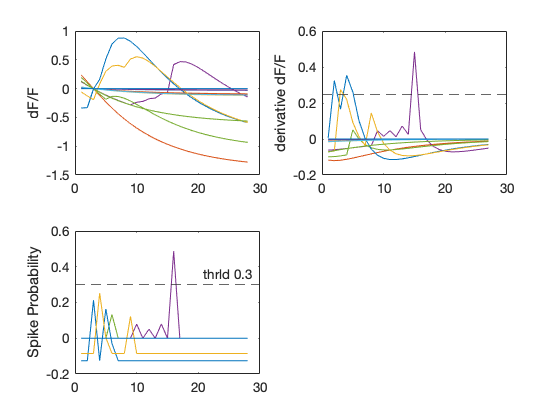

In [149]:
% Compare Spike Probability with dF/F

t_start = 8;
frameRate = 7.4811;
t_end = t_start + round(tbin*frameRate);

ntrials = 15;
cutoff = 0.3;
% plot(dat_sorted{fov}.deNoise_dff.ROI120.d1.')
roi = 'ROI120';
subplot(2,2,1)
plot(dat_sorted{fov}.deNoise_dff.(roi).d1(1:ntrials,:).');
ylabel('dF/F')

subplot(2,2,2)
plot(diff(dat_sorted{fov}.deNoise_dff.(roi).d1(1:ntrials,:),1, 2).');
yline(0.25,'--');
ylabel('derivative dF/F')

subplot(2,2,3)
plot(dat_sorted{fov}.spike.(roi).d1(1:ntrials,:).')
yline(cutoff,'--',['thrld ',num2str(cutoff)]);
ylabel('Spike Probability')

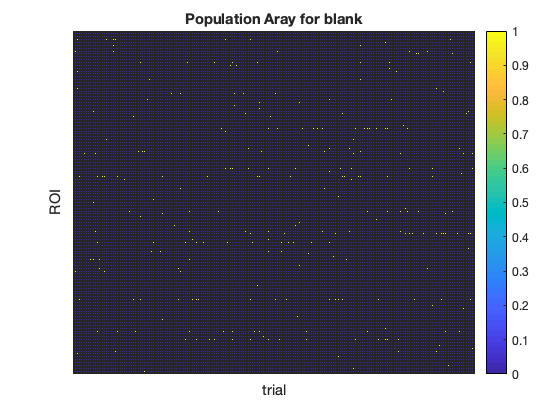

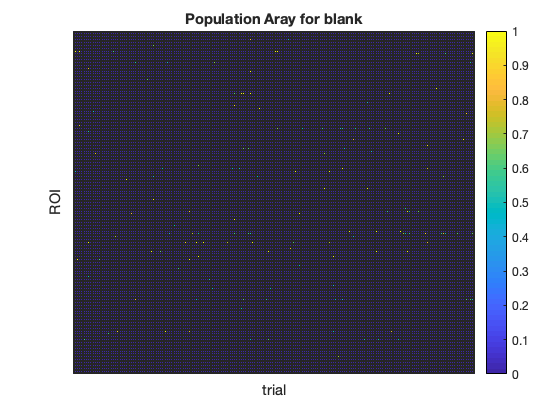

In [150]:
% Build Spike Probability Based Population Array

thrld_spk = 0.4;
[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);

figure(1)
plot_poparray(stim_PA(1:223,:).', 10)
colormap default
caxis([0,1])

figure(2)
plot_poparray(stim_PA_sp(1:223,:).', 10)
colormap default
caxis([0,1])

Spike probability captures a different subset of trials with active ROIS, although they somewhat overlap

Mean Spontaneous Firing Probability: 4.6031e-05


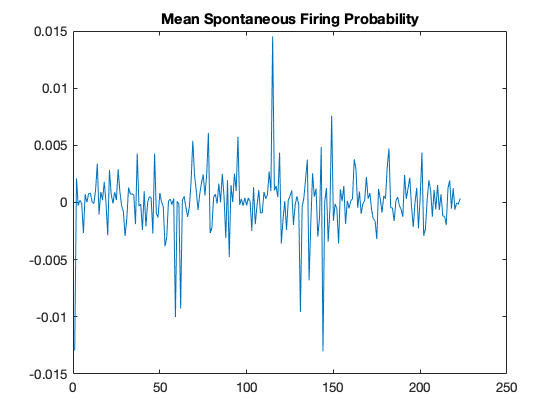

In [157]:
% quantify correspondance of spk prob with avg firing rate - blank trials
spont_all = [];
for r = 1:num_rois
    roi = ['ROI', num2str(r)];
    stim_spkprob = dat_sorted{fov}.spike.(roi).blank(:);
    spont_all = [spont_all, stim_spkprob];
end

mean_spont_all = mean(spont_all);
plot(mean_spont_all)
title('Mean Spontaneous Firing Probability')
disp(['Mean Spontaneous Firing Probability: ', num2str(mean(spont_all,'all'))])

Using the mean spiking probability for the blank trials results in a poor correspondance between spontaneous firing rate and spike probability due to the sparse spiking probability. 

## 2. PCA on PA using spike probability 

CaImAn uses a sparse non-negative deconvolution algorithm to estimate the spike probability from the dF/F data

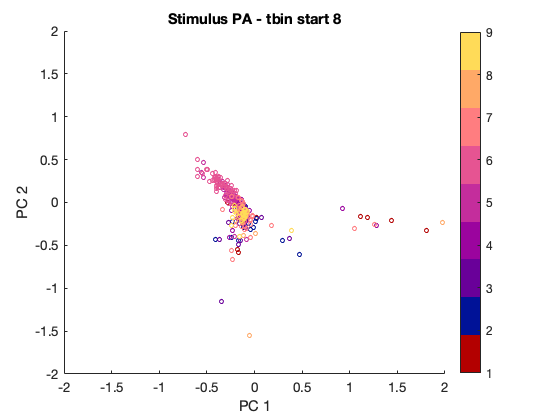

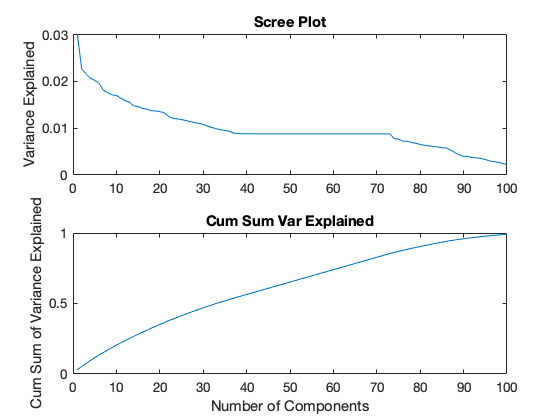

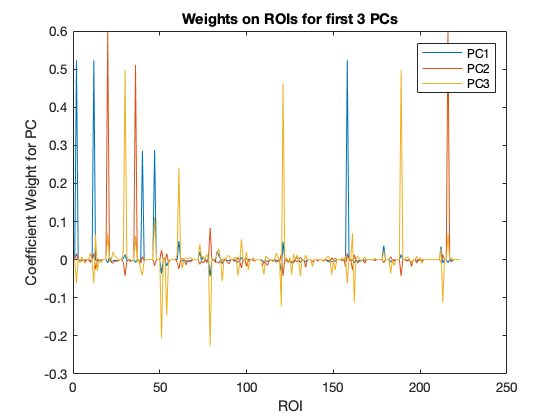

In [205]:
thrld_spk = 0.5;
fov = 4;

[stim_PA_sp, stim_label] = get_spkprob_PA(dat_sorted,fov,thrld_spk, stim_onset, tbin);
stim_PA_zscore = zscore(stim_PA_sp);
[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA_zscore, 'Centered', false);
% [PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA_sp, 'Centered', true);

figure(1)
plot_PCAscores(PCA_allstim.score(:,1),PCA_allstim.score(:,2), stim_label, ['Stimulus PA - tbin start ',num2str(t_start)])

% Variance Explained 
figure(2)
var_exp = plot_scree(PCA_allstim.latent/sum(PCA_allstim.latent));

figure(3)
plot(PCA_allstim.coeff(:,1:3))
xlabel('ROI')
ylabel('Coefficient Weight for PC')
title('Weights on ROIs for first 3 PCs')
legend('PC1', 'PC2', 'PC3')

Because the population array is no longer binary, the variance for each ROI is large and the PA needs to be z-scored. The new PCs are weighted over a larger selection of cells, and the previous structure is lost

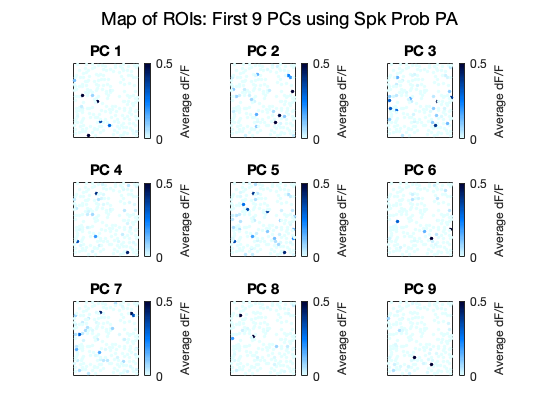

In [204]:
%Plot PC weights for spatially organized ROIs

nPCs = 9;
% Get ROI Positions 
x_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
y_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1); 

for i = 1:numel(fields(ROI_position{fov}.ROI_centroids))
    roi = ['ROI', num2str(i)];
    x_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(1);
    y_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(2);
end

for feature = 1:nPCs
    subplot(3,3,feature)
    plot_clusteronROIS(x_pst, y_pst, PCA_allstim.coeff(:,feature), ['PC ',num2str(feature)],8)
%     caxis([0,0.3])
    
end
sgtitle('Map of ROIs: First 9 PCs using Spk Prob PA')

## 3. Weighted PCA using Whisker Responsivness 

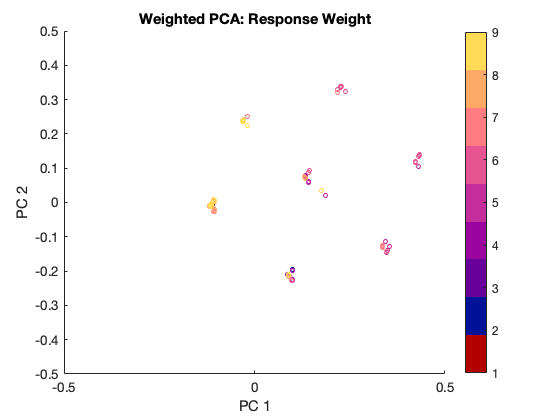

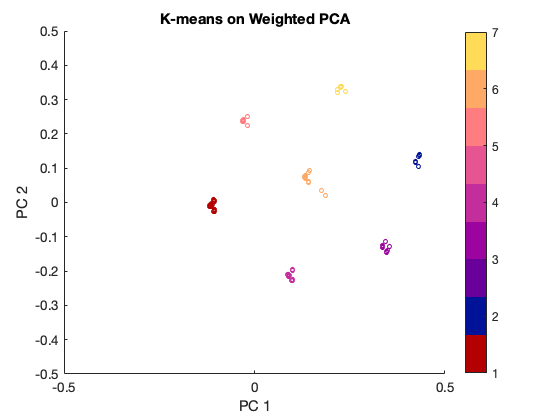

In [231]:
% Response Weight 
[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);

mean_resp = [];
for stim_num = 1: length(stimulus)-1
    events_stim = get_spikes_stim(dat_sorted,fov,thrld, stim_onset, tbin, stim_num);
    mean_resp = [mean_resp, mean(events_stim,2)];
end
w_resp = max(mean_resp.').';
w_resp = w_resp/sum(w_resp);
w_resp(w_resp==0) = 0.0001;

[wcoeff,wscore,wlatent] = pca(stim_PA, 'Centered', true, 'VariableWeights', w_resp);
plot_PCAscores(wscore(:,1),wscore(:,2), stim_label,'Weighted PCA: Response Weight')
xlim([-0.5,0.5])
ylim([-0.5,0.5])

cluster_num = 7;
[cluster_lbls,centroid_locs,sumd] = kmeans(wscore(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
figure(2)
plot_PCA(wscore, cluster_lbls, 'K-means on Weighted PCA')
xlim([-0.5,0.5])
ylim([-0.5,0.5])

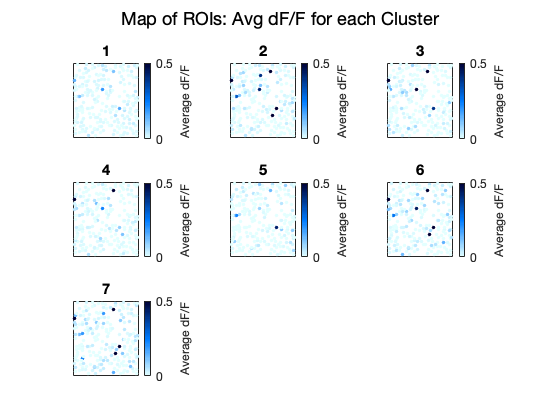

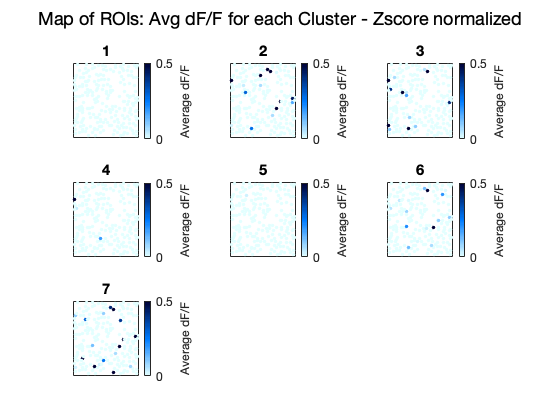

In [232]:
% Get dFF for all trials within cluster 
cluster_info = cluster_idxs(dat_sorted,fov, cluster_lbls, stim_label);
[cluster_info,cluster_dff_avg, cluster_dff_avg_norm] = get_dff_cluster(data, dat_sorted, fov, cluster_info, tbin);     

%Plot average dF/F on map of ROIs
figure(1)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster')

% Z-score dF/F
figure(2)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_norm(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster - Zscore normalized')

Using weighted PCA to find the spatial clusters results in the same number of clusters vs normal PCA. The cells  within the cluster however are different. 


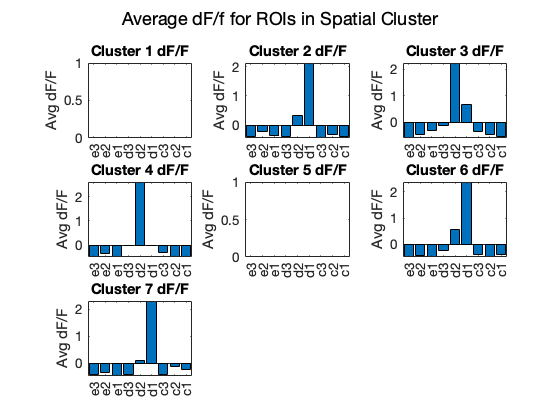

In [234]:
% Get dF/F for Cells within Cluster for each whisker stimulus type 
cutoff = 0.3;
spatial_clusters = get_spatial_cluster(dat_sorted, data, cluster_dff_avg_norm, cutoff, cluster_num, fov, t_start, tbin);

%Plot whisker tuning for each ROI in each cluster for all clusters  

whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

% Mean Whisker Receptive Field for ROIs in Cluster

for clusters = 1: length(spatial_clusters)
    y = zscore(spatial_clusters{clusters}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(3,3,clusters)
    bar(x,whisk_resp_avg)
    ylabel('Avg dF/F')
    title(['Cluster ', num2str(clusters),' dF/F'])
end
sgtitle('Average dF/f for ROIs in Spatial Cluster')